In [3]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as no
from tensorflow import keras

In [4]:
(X_train , y_train) , (X_test , y_test) = keras.datasets.mnist.load_data()

In [5]:
len(X_train)

60000

In [6]:
len(X_test)

10000

In [8]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

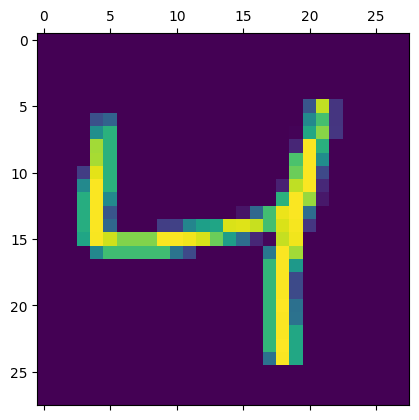

In [9]:
plt.matshow(X_train[2])

In [11]:
y_train[2]

np.uint8(4)

### Convert into 1d array

In [14]:
X_train.shape

(60000, 28, 28)

In [33]:
X_train = X_train /255 ## Scaling
X_test = X_test /255

In [28]:
X_train_flattened = X_train.reshape(len(X_train),28*28)

In [29]:
X_train_flattened.shape

(60000, 784)

In [30]:
X_test.shape

(10000, 28, 28)

In [31]:
X_test_flattened = X_test.reshape(len(X_test),28*28)
X_test_flattened.shape

(10000, 784)

# Simple NN with two layers

In [32]:
model = keras.Sequential([
    keras.layers.Dense(
        10,
        input_shape=(784,),
        activation='sigmoid'
    )
])  # neurons in one layer connected to output layer

# 10 outputs representing digits 0–9

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train_flattened, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 342us/step - accuracy: 0.8769 - loss: 0.4709
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 348us/step - accuracy: 0.9159 - loss: 0.3035
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 346us/step - accuracy: 0.9207 - loss: 0.2832
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 363us/step - accuracy: 0.9241 - loss: 0.2734
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 349us/step - accuracy: 0.9259 - loss: 0.2666


In [34]:
model.evaluate(X_test_flattened , y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 363us/step - accuracy: 0.9247 - loss: 0.2696


[0.2695809006690979, 0.9247000217437744]

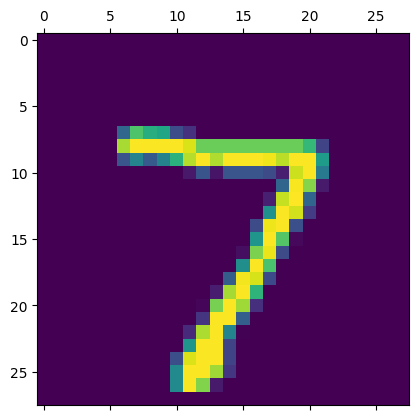

In [36]:
plt.matshow(X_test[0])

In [38]:
y_pred = model.predict(X_test_flattened)
y_pred[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 250us/step


array([3.75433490e-02, 4.53632538e-07, 6.06654398e-02, 9.59946930e-01,
       2.19763815e-03, 1.26476645e-01, 1.83723046e-06, 9.99764025e-01,
       1.02591395e-01, 6.38276041e-01], dtype=float32)

In [40]:
import numpy as np

In [41]:
np.argmax(y_pred[0])

np.int64(7)

In [44]:
y_pred_labels = [np.argmax(i) for i in y_pred]
y_pred_labels[:3]

[np.int64(7), np.int64(2), np.int64(1)]

In [45]:
cm = tf.math.confusion_matrix(labels = y_test , predictions = y_pred_labels)

In [46]:
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 966,    0,    0,    2,    0,    4,    5,    2,    1,    0],
       [   0, 1111,    3,    2,    0,    1,    4,    2,   12,    0],
       [   9,    9,  920,   17,    8,    3,   13,   11,   40,    2],
       [   5,    0,   20,  918,    0,   24,    2,   12,   23,    6],
       [   2,    1,    3,    1,  908,    0,   12,    5,   11,   39],
       [  13,    2,    3,   31,    8,  776,   17,    5,   30,    7],
       [  13,    3,    7,    1,    7,   11,  913,    2,    1,    0],
       [   2,    6,   23,    6,    8,    1,    0,  952,    2,   28],
       [  12,    7,    6,   20,    8,   25,   10,   12,  867,    7],
       [  11,    7,    1,    9,   23,    9,    0,   28,    5,  916]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'truth')

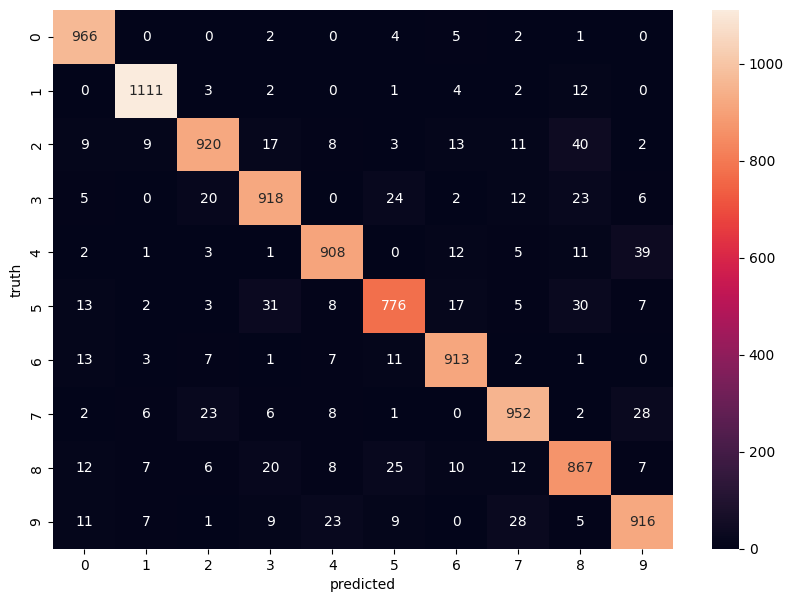

In [49]:
import seaborn as sns
plt.figure(figsize = (10,7))
sns.heatmap(cm , annot =True , fmt = 'd')
plt.xlabel("predicted")
plt.ylabel("truth")

## Hidden layer added

In [50]:
model = keras.Sequential([
    keras.layers.Dense(
        100,
        input_shape=(784,),
        activation='relu'
    ), ## hidden layer 
    keras.layers.Dense(10,activation = 'sigmoid')
]) 

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train_flattened, y_train, epochs=5)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 682us/step - accuracy: 0.9198 - loss: 0.2820
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 686us/step - accuracy: 0.9631 - loss: 0.1277
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 639us/step - accuracy: 0.9731 - loss: 0.0891
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 661us/step - accuracy: 0.9796 - loss: 0.0672
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 630us/step - accuracy: 0.9840 - loss: 0.0533


In [52]:
model.evaluate(X_test_flattened , y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 401us/step - accuracy: 0.9766 - loss: 0.0805


[0.08052368462085724, 0.9765999913215637]

Text(95.72222222222221, 0.5, 'truth')

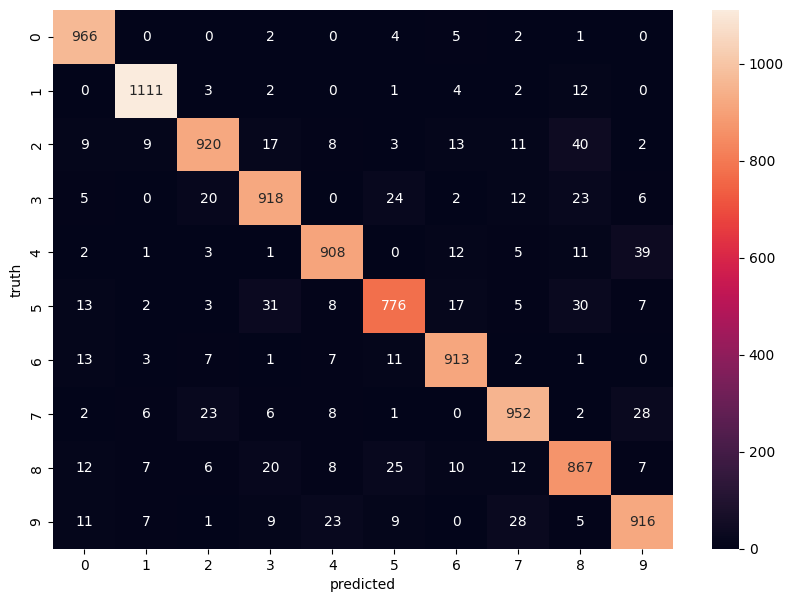

In [54]:
y_pred_labels = [np.argmax(i) for i in y_pred]
y_pred_labels[:3]
cm = tf.math.confusion_matrix(labels = y_test , predictions = y_pred_labels)

import seaborn as sns
plt.figure(figsize = (10,7))
sns.heatmap(cm , annot =True , fmt = 'd')
plt.xlabel("predicted")
plt.ylabel("truth")

In [56]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape = (28,28)),
    keras.layers.Dense(
        100,
        input_shape=(784,),
        activation='relu'
    ), ## hidden layer 
    keras.layers.Dense(10,activation = 'sigmoid')
]) 

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=5)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 634us/step - accuracy: 0.7085 - loss: 1.2615
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 625us/step - accuracy: 0.8620 - loss: 0.5370
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 627us/step - accuracy: 0.8881 - loss: 0.4095
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 658us/step - accuracy: 0.9001 - loss: 0.3591
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 629us/step - accuracy: 0.9066 - loss: 0.3318
